In [9]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### Funciones de prueba

In [2]:
# -------------------------------
# FUNCIONES DE PRUEBA
# -------------------------------

def sphere_torch(x):
    return torch.sum(x**2)

def rosenbrock_torch(x):
    return torch.sum(100 * (x[1:] - x[:-1]**2)**2 + (x[:-1] - 1)**2)

def rastrigin_torch(x):
    A = 10
    return A * x.shape[0] + torch.sum(x**2 - A * torch.cos(2 * np.pi * x))

def griewank_torch(x):
    sum_term = torch.sum(x**2) / 4000
    prod_term = torch.prod(torch.cos(x / torch.sqrt(torch.arange(1, x.shape[0]+1, dtype=torch.float32))))
    return sum_term - prod_term + 1


def schwefel_torch(x):
    return 418.9829 * x.shape[0] - torch.sum(x * torch.sin(torch.sqrt(torch.abs(x))))

funciones_torch = {
    "Sphere": sphere_torch,
    "Rosenbrock": rosenbrock_torch,
    "Rastrigin": rastrigin_torch,
    "Griewank": griewank_torch,
    "Schwefel": schwefel_torch
}

## Aloritmos de Optimización

### Descenso del gradiente

In [3]:
# -------------------------------
# GRADIENTE DESCENDENTE
# -------------------------------
def gradient_descent_torch(func, x, lr=0.01, max_iter=100):
    fitness_history = []

    if func.__name__ == 'rosenbrock_torch':
        x = x.clone().detach().requires_grad_(True)
        optimizer = torch.optim.Adam([x], lr=lr)
        for _ in range(max_iter):
            optimizer.zero_grad()
            y = func(x)
            y.backward()
            optimizer.step()
            fitness_history.append(y.item())
    else:
        for _ in range(max_iter):
            y = func(x)
            y.backward()
            with torch.no_grad():
                x -= lr * x.grad
                x.grad.zero_()
            fitness_history.append(y.item())

    return fitness_history

### Algoritmo Genético (GA)

In [4]:
# -------------------------------
# ALGORITMO GENÉTICO
# -------------------------------

def genetic_algorithm(func, dim, pop_size=50, generations=100, bounds=(-5, 5), mutation_rate=0.1):
    pop = np.random.uniform(bounds[0], bounds[1], (pop_size, dim))
    fitness_history = []

    for _ in range(generations):
        fitness = np.array([func(torch.tensor(ind, dtype=torch.float32)) for ind in pop])
        best_fitness = np.min(fitness)
        fitness_history.append(best_fitness)

        idx = np.argsort(fitness)
        pop = pop[idx]
        parents = pop[:pop_size//2]

        # Crossover
        children = []
        while len(children) < pop_size // 2:
            p1, p2 = parents[np.random.randint(len(parents))], parents[np.random.randint(len(parents))]
            cross_point = np.random.randint(1, dim - 1)
            child = np.concatenate([p1[:cross_point], p2[cross_point:]])
            children.append(child)

        # Mutación
        for child in children:
            if np.random.rand() < mutation_rate:
                idx = np.random.randint(0, dim)
                child[idx] += np.random.normal()

        pop = np.vstack((parents, children))

    return fitness_history

### Algoritmo de Enjambre de Partículas (PSO)

In [5]:
# -------------------------------
# PSO
# -------------------------------

def pso(func, dim, num_particles=30, iterations=100, bounds=(-5, 5), w=0.5, c1=1.5, c2=1.5):
    pos = np.random.uniform(bounds[0], bounds[1], (num_particles, dim))
    vel = np.zeros_like(pos)

    personal_best = pos.copy()
    personal_best_val = np.array([func(torch.tensor(p, dtype=torch.float32)) for p in pos])
    global_best = personal_best[np.argmin(personal_best_val)]

    fitness_history = []

    for _ in range(iterations):
        for i in range(num_particles):
            r1, r2 = np.random.rand(), np.random.rand()
            vel[i] = w * vel[i] + c1 * r1 * (personal_best[i] - pos[i]) + c2 * r2 * (global_best - pos[i])
            pos[i] += vel[i]
            pos[i] = np.clip(pos[i], bounds[0], bounds[1])

            val = func(torch.tensor(pos[i], dtype=torch.float32))
            if val < personal_best_val[i]:
                personal_best[i] = pos[i]
                personal_best_val[i] = val

        global_best = personal_best[np.argmin(personal_best_val)]
        best_val = np.min(personal_best_val)
        fitness_history.append(best_val)

    return fitness_history

### Experimentos

In [6]:
# -------------------------------
# CONFIGURACIÓN EXPERIMENTAL
# -------------------------------

dim = 5
runs = 20
iterations = 100

# Almacena promedios
resultados = {
    "GradientDescent": {},
    "GeneticAlgorithm": {},
    "PSO": {}
}

for name, func_torch in funciones_torch.items():
    resultados["GradientDescent"][name] = []
    resultados["GeneticAlgorithm"][name] = []
    resultados["PSO"][name] = []

    for _ in range(runs):
        # GD
        x0 = torch.tensor(np.random.uniform(-5, 5, dim), dtype=torch.float32, requires_grad=True)
        gd_history = gradient_descent_torch(func_torch, x0)
        resultados["GradientDescent"][name].append(gd_history)

        # GA
        ga_history = genetic_algorithm(func_torch, dim)
        resultados["GeneticAlgorithm"][name].append(ga_history)

        # PSO
        pso_history = pso(func_torch, dim)
        resultados["PSO"][name].append(pso_history)


### Gráficas

In [13]:
import os

os.makedirs("graficas", exist_ok=True)

for func_name in funciones_torch.keys():
    plt.figure(figsize=(10, 6))
    for method in resultados.keys():
        histories = np.array(resultados[method][func_name])
        mean_fitness = np.mean(histories, axis=0)
        plt.plot(mean_fitness, label=method)

    plt.title(f"Evolución Promedio de Fitness - {func_name}")
    plt.xlabel("Iteraciones")
    plt.ylabel("Fitness")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Guarda la figura como imagen PNG
    plt.savefig(f"graficas/{func_name}_evolucion_fitness.png")
    plt.close()  # Cierra la figura para liberar memoria


### Estadísticos

In [11]:
import numpy as np

# Cálculo de estadísticas
estadisticos = {
    "GradientDescent": {},
    "GeneticAlgorithm": {},
    "PSO": {}
}

# Calculamos la media, mediana y desviación estándar de los resultados
for name, func_torch in funciones_torch.items():
    estadisticos["GradientDescent"][name] = {
        "mean": np.mean(resultados["GradientDescent"][name], axis=0),
        "median": np.median(resultados["GradientDescent"][name], axis=0),
        "std": np.std(resultados["GradientDescent"][name], axis=0)
    }
    estadisticos["GeneticAlgorithm"][name] = {
        "mean": np.mean(resultados["GeneticAlgorithm"][name], axis=0),
        "median": np.median(resultados["GeneticAlgorithm"][name], axis=0),
        "std": np.std(resultados["GeneticAlgorithm"][name], axis=0)
    }
    estadisticos["PSO"][name] = {
        "mean": np.mean(resultados["PSO"][name], axis=0),
        "median": np.median(resultados["PSO"][name], axis=0),
        "std": np.std(resultados["PSO"][name], axis=0)
    }

# Mostrar los resultados
for method in estadisticos.keys():
    print(f"\n{method}:")
    for func_name in estadisticos[method].keys():
        print(f"\n{func_name}:")
        print(f"  Media: {estadisticos[method][func_name]['mean'][-1]:.4f}")
        print(f"  Mediana: {estadisticos[method][func_name]['median'][-1]:.4f}")
        print(f"  Desviación Estándar: {estadisticos[method][func_name]['std'][-1]:.4f}")



GradientDescent:

Sphere:
  Media: 0.8521
  Mediana: 0.8223
  Desviación Estándar: 0.3374

Rosenbrock:
  Media: 24054.3118
  Mediana: 19125.5566
  Desviación Estándar: 17051.6103

Rastrigin:
  Media: 79.8343
  Mediana: 81.7275
  Desviación Estándar: 17.3116

Griewank:
  Media: 0.9900
  Mediana: 1.0037
  Desviación Estándar: 0.0767

Schwefel:
  Media: 2090.8158
  Mediana: 2090.9200
  Desviación Estándar: 4.0814

GeneticAlgorithm:

Sphere:
  Media: 0.0118
  Mediana: 0.0097
  Desviación Estándar: 0.0089

Rosenbrock:
  Media: 14.8733
  Mediana: 2.8692
  Desviación Estándar: 34.9014

Rastrigin:
  Media: 2.5729
  Mediana: 2.4403
  Desviación Estándar: 0.8936

Griewank:
  Media: 0.0114
  Mediana: 0.0110
  Desviación Estándar: 0.0060

Schwefel:
  Media: 2075.1909
  Mediana: 2075.1904
  Desviación Estándar: 0.0016

PSO:

Sphere:
  Media: 0.0000
  Mediana: 0.0000
  Desviación Estándar: 0.0000

Rosenbrock:
  Media: 10.1531
  Mediana: 1.5846
  Desviación Estándar: 34.6059

Rastrigin:
  Media: 10.

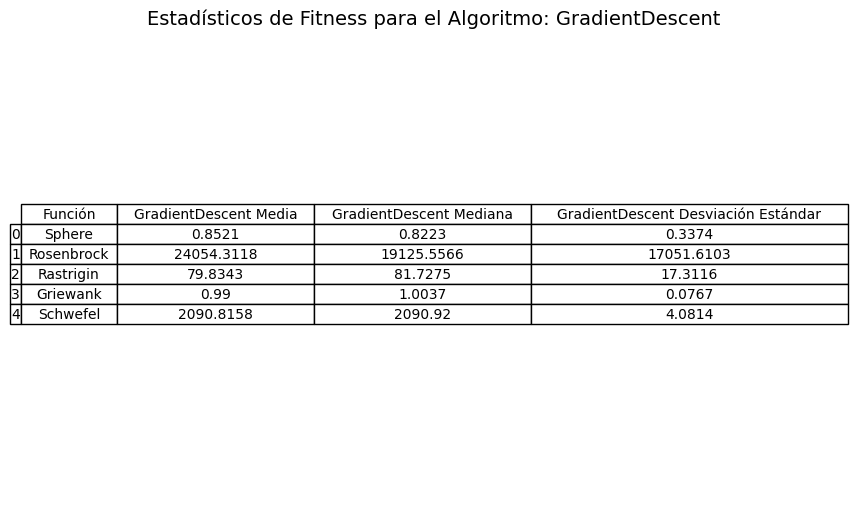

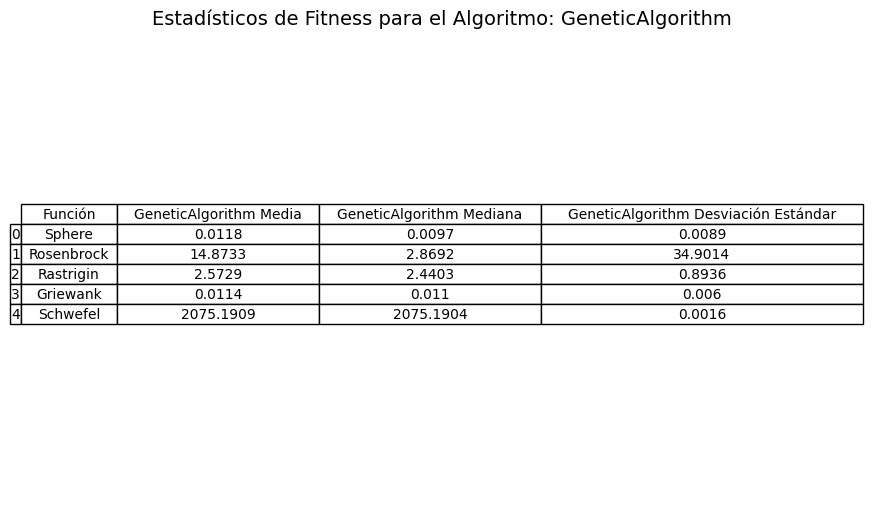

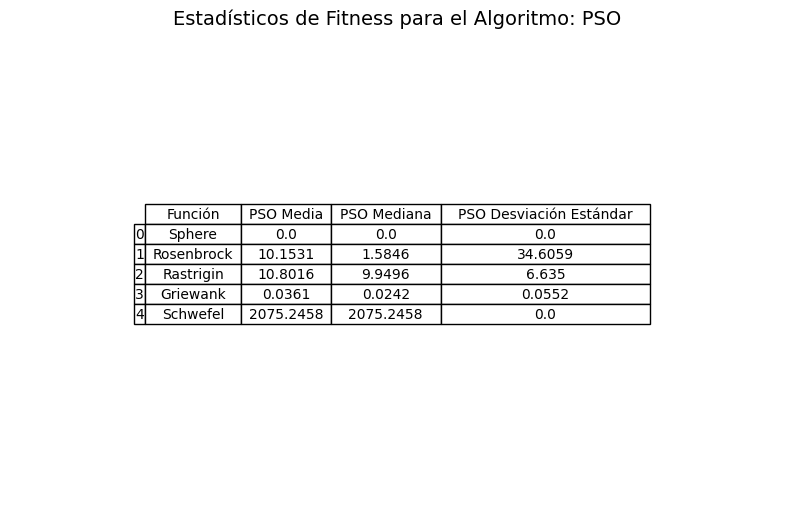

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import table

# Función para redondear los resultados
def round_tensor(tensor, decimals=4):
    return round(tensor.item(), decimals)

# Crear una función para mostrar la tabla
def mostrar_tabla_por_algoritmo(df, algoritmo):
    fig, ax = plt.subplots(figsize=(10, 6))  # Tamaño de la figura
    ax.axis('off')  # Ocultamos los ejes

    # Dibujamos la tabla
    tabla = table(ax, df, loc='center', cellLoc='center', colWidths=[0.2] * len(df.columns))

    # Mejoramos el diseño de la tabla
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)
    tabla.scale(1.2, 1.2)  # Escala la tabla

    # Ajustar el ancho de las columnas
    tabla.auto_set_column_width([i for i in range(len(df.columns))])  

    # Título
    plt.title(f"Estadísticos de Fitness para el Algoritmo: {algoritmo}", fontsize=14)
    plt.show()

# Crear las tablas por algoritmo
for method in ["GradientDescent", "GeneticAlgorithm", "PSO"]:
    data = []

    # Recolectamos los estadísticos de media, mediana y desviación estándar por función
    for func_name in funciones_torch.keys():
        row = [func_name]
        
        # Redondeamos los valores de media, mediana y desviación estándar a 4 decimales
        mean_val = round_tensor(estadisticos[method][func_name]["mean"][-1], 4)
        median_val = round_tensor(estadisticos[method][func_name]["median"][-1], 4)
        std_val = round_tensor(estadisticos[method][func_name]["std"][-1], 4)
        
        row.extend([mean_val, median_val, std_val])
        data.append(row)

    # Crear el DataFrame
    columns = ["Función", f"{method} Media", f"{method} Mediana", f"{method} Desviación Estándar"]
    df = pd.DataFrame(data, columns=columns)

    # Mostrar la tabla separada por algoritmo
    mostrar_tabla_por_algoritmo(df, method)
